# Практическая работа № 1

## Теоретическая справка

**Цель работы:** попробовать на практике базовые инструменты компьютерного зрения и научиться работать с изображениями, а также понять, как различные операции влияют на изображение и для чего они могут быть полезны.


**Задачи:**

1. Изучить базовые методы загрузки и отображения изображений.
2. Попробовать изменения размера, повороты и отражения изображений.
3. Применить размытие с разным количеством ядер.
4. Протестировать алгоритм выделения границ с разными параметрами.
5. Сформировать отчет с теоретическим обоснованием и выводами.

**Используемые инструменты:**

1. **OpenCV** – библиотека для компьютерного зрения и обработки изображений. Позволяет загружать и отображать изображения, изменять размер, поворачивать, применять фильтры и преобразования, анализировать изображение на основе цветовой информации, форм и контуров.

Основные методы, используемые в работе:

* cv2.imread() – загрузка изображения
* cv2.cvtColor() – преобразование цветового пространства
* cv2.resize() – изменение размера изображения
* cv2.warpAffine() и cv2.getRotationMatrix2D() – поворот и масштабирование
* cv2.flip() – отражение изображения по горизонтали или вертикали
* cv2.GaussianBlur() – размытие изображения с использованием гауссового фильтра
* cv2.Canny(), cv2.Sobel() – выделение границ объектов на изображении

Все операции позволяют изменять внешний вид изображения и подготавливать его для последующего анализа и работы с моделями компьютерного зрения.

2. **NumPy** – библиотека для работы с многомерными массивами, используется для хранения изображений и математических операций над ними.

3. **Matplotlib** – библиотека для визуализации изображений и графиков, позволяет наглядно показывать результаты обработки.



In [7]:
# Используемые библиотеки
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 1. Работа с изображением

Загрузим изображение с помощью `cv2.imread()`. OpenCV по умолчанию загружает изображение в формате BGR, поэтому преобразуем его в формат RGB с помощью `cv2.cvtColor()`, чтобы корректно отображать в matplotlib.

Выведем размер изображения с помощью `img_rgb.shape`. Размерность включает три параметра: высоту, ширину и количество цветовых каналов.

Размер изображения: (1709, 2560, 3)


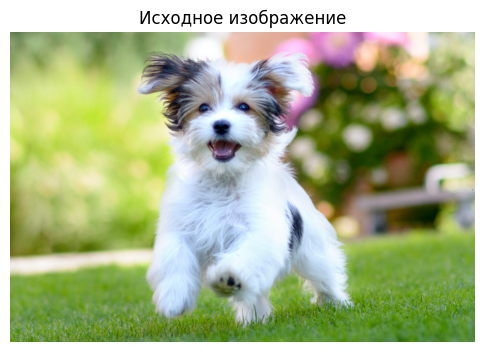

In [9]:
image_path = "dog.jpeg"
img_bgr = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print("Размер изображения:", img_rgb.shape)
plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title("Исходное изображение")
plt.axis("off")
plt.show()

Используем функцию `cv2.resize()` для изменения размеров изображения.

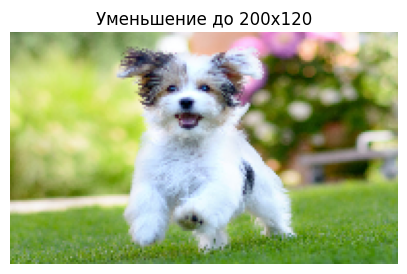

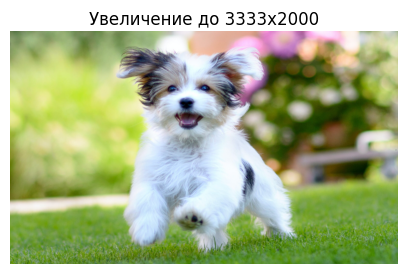

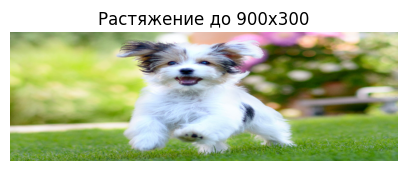

In [16]:
# Уменьшение изображения
resized_small = cv2.resize(img_rgb, (200, 120))
plt.figure(figsize=(5,5))
plt.imshow(resized_small)
plt.title("Уменьшение до 200x120")
plt.axis("off")
plt.show()

# Увеличение изображения
resized_large = cv2.resize(img_rgb, (3333, 2000))
plt.figure(figsize=(5,5))
plt.imshow(resized_large)
plt.title("Увеличение до 3333x2000")
plt.axis("off")
plt.show()

# Растяжение изображения
resized_stretch = cv2.resize(img_rgb, (900, 300))
plt.figure(figsize=(5,5))
plt.imshow(resized_stretch)
plt.title("Растяжение до 900x300")
plt.axis("off")
plt.show()

Меньшее изображение показывает упрощённую версию исходного, с потерей некоторых деталей. Увеличенное изображение позволяет рассмотреть детали, но может возникнуть легкая размытость. Растянутое изображение искажено, так как соотношение сторон изменилось.

Уменьшение ускоряет обработку и уменьшает расход памяти, полезно для предварительной обработки и анализа большого числа изображений. Увеличение помогает рассмотреть мелкие детали или подготовить изображение к визуализации. Растяжение может использоваться для подгонки изображения под конкретные размеры сетки.

Попробуем повернуть изображение на разные углы. Для этого получаем размеры исходного изображения, определяем центр поворота, вокруг которого будет происходить вращение. Используем функцию OpenCV для получения матрицы поворота и применяем `cv2.warpAffine()`, который изменяет координаты каждого пикселя в соответствии с матрицей.

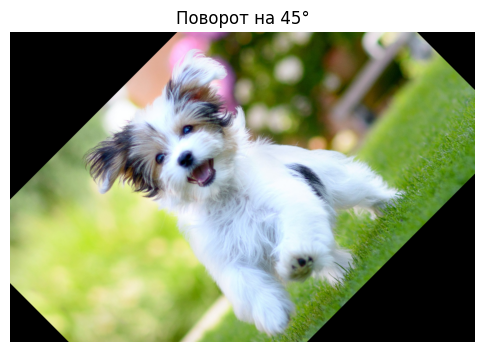

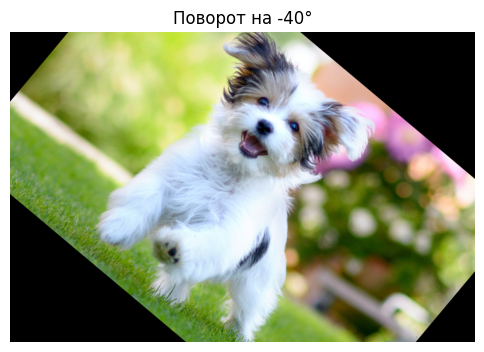

In [22]:
(h, w) = img_rgb.shape[:2]
center = (w // 2, h // 2)

# Поворот на 45 градусов
angle = 45
scale = 1.0
rotation_matrix = cv2.getRotationMatrix2D(center, angle, scale)
rotated_45 = cv2.warpAffine(img_rgb, rotation_matrix, (w, h))

plt.figure(figsize=(6,6))
plt.imshow(rotated_45)
plt.title("Поворот на 45°")
plt.axis("off")
plt.show()

# Поворот на -40 градусов
angle = -40
rotation_matrix = cv2.getRotationMatrix2D(center, angle, scale)
rotated_minus30 = cv2.warpAffine(img_rgb, rotation_matrix, (w, h))

plt.figure(figsize=(6,6))
plt.imshow(rotated_minus30)
plt.title("Поворот на -40°")
plt.axis("off")
plt.show()

Все объекты на изображении сохраняют свою форму относительно центра. Поворот изображения полезен для создания новых вариантов изображения при обучении моделей компьютерного зрения, выравнивания объектов, визуализации.

Используем функцию `cv2.flip()` для отражения изображения. Аргумент 1 - горизонтальное отражение (относительно вертикальной оси), аргумент 0 - вертикальное отражение (относительно горизонтальной оси).

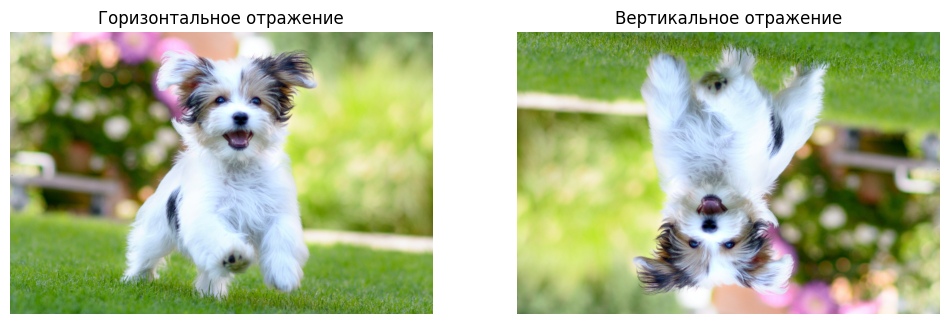

In [24]:
flipped_horizontal = cv2.flip(img_rgb, 1)
flipped_vertical = cv2.flip(img_rgb, 0)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(flipped_horizontal)
plt.title("Горизонтальное отражение")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(flipped_vertical)
plt.title("Вертикальное отражение")
plt.axis("off")
plt.show()

Отражение помогает увеличить количество тренировочных изображений без создания новых, также полезно в задачах распознавания, когда ориентация объектов может меняться.

Применим гауссово размытие к изображению с разными размерами ядра с помощью `cv2.GaussianBlur()`. Второй аргумент (k,k) – размер ядра фильтра, где k должно быть нечетным. Чем больше ядро, тем сильнее размытие. Третий аргумент – стандартное отклонение гауссовой функции (при 0 OpenCV сам выбирает оптимальное значение).

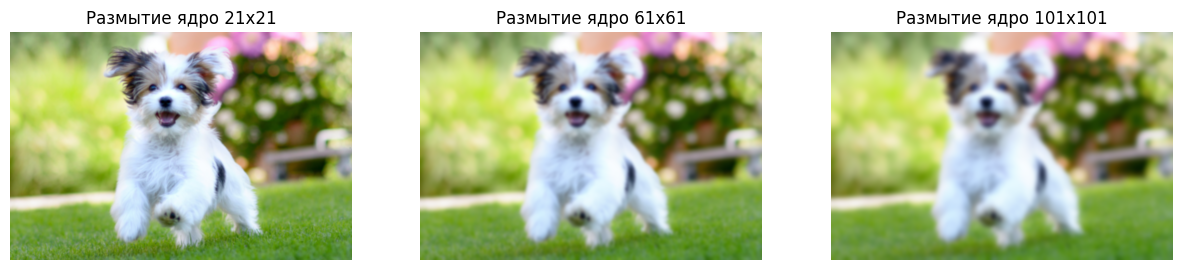

In [30]:
blur_small = cv2.GaussianBlur(img_rgb, (21,21), 0)
blur_medium = cv2.GaussianBlur(img_rgb, (61,61), 0)
blur_large = cv2.GaussianBlur(img_rgb, (101,101), 0)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(blur_small)
plt.title("Размытие ядро 21x21")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(blur_medium)
plt.title("Размытие ядро 61x61")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(blur_large)
plt.title("Размытие ядро 101x101")
plt.axis("off")
plt.show()

Полезно перед обработкой изображений, например, перед выделением границ или распознаванием объектов. Уменьшает влияние мелких деталей, чтобы алгоритмы сосредоточились на крупных структурах.

## 2. Выделение границ

Преобразуем исходное изображение в оттенки серого с помощью `cv2.cvtColor()`, потому что алгоритмы выделения границ работают с одноцветными изображениями.

Применим алгоритм Canny дважды с разными порогами:
* (45, 80) – нижний порог ниже, поэтому больше шумных деталей и мелких линий
* (100, 150) – выше пороги, шум снижен, границы четче, но некоторые мелкие детали теряются

Для сравнения применим метод Собеля, который вычисляет градиенты яркости по горизонтали и вертикали, а затем объединяет их для общей карты границ. `cv2.magnitude()` комбинирует оба градиента, чтобы получить полную карту границ.

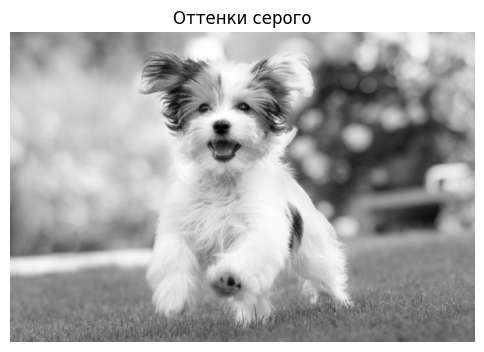

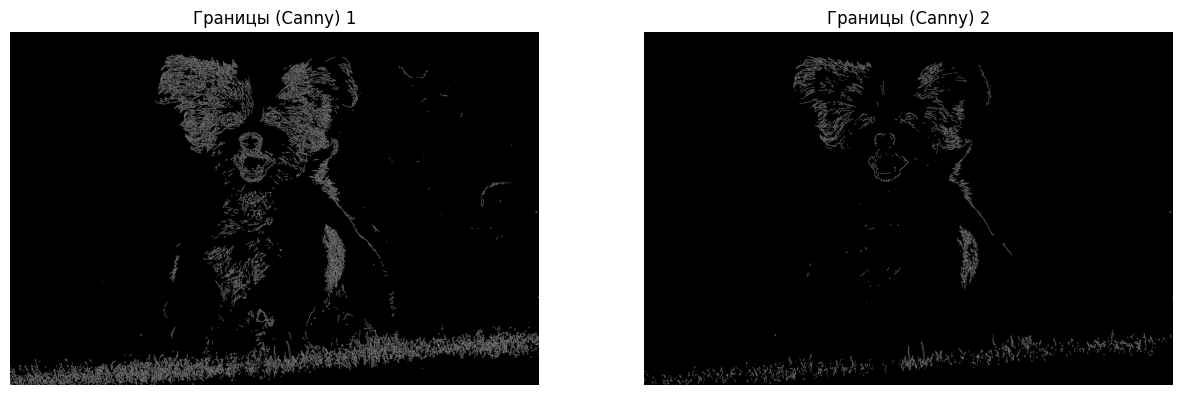

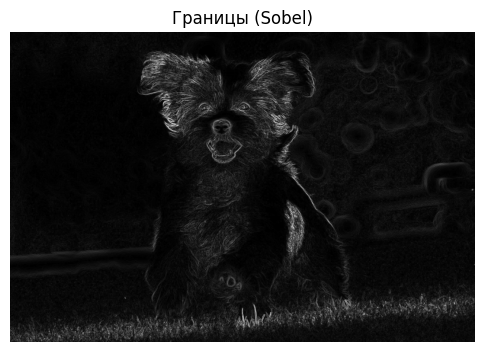

In [58]:
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Canny
edges1 = cv2.Canny(gray, 45, 80)
edges2 = cv2.Canny(gray, 100, 150)

# Метод Собеля (Sobel)
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
sobel_combined = cv2.magnitude(sobelx, sobely)
sobel_combined = cv2.convertScaleAbs(sobel_combined)

plt.figure(figsize=(6,6))
plt.imshow(gray, cmap="gray")
plt.title("Оттенки серого")
plt.axis("off")
plt.show()

plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.imshow(edges1, cmap="gray")
plt.title("Границы (Canny) 1")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(edges2, cmap="gray")
plt.title("Границы (Canny) 2")
plt.axis("off")
plt.show()

plt.figure(figsize=(6,6))
plt.imshow(sobel_combined, cmap="gray")
plt.title("Границы (Sobel)")
plt.axis("off")
plt.show()

1. Canny (45, 80) – хорошо видны очертания объектов, но много шумных линий и мелких деталей.
2. Canny (100, 150) – шум снижен, границы собаки четче, но мелкие детали теряются.
3. Sobel – лучший результат для этого изображения: границы собаки выделены ясно и плавно, контуры деталей хорошо видны, при этом шум минимален.

Для данного изображения Sobel работает лучше всего, так как изображение реалистичное, с плавными переходами яркости и текстурой шерсти собаки. Canny в данном случае немного хуже справляется с выделением границ.

## Общий вывод

В ходе практической работы были изучены базовые методы обработки изображений с использованием библиотеки OpenCV. Уменьшение и увеличение меняют детализацию, повороты и отражения создают новые варианты изображения для анализа, размытие помогает снизить шум, а методы выделения границ — выделить контуры объектов. Для данного изображения метод Sobel показал наилучший результат для выделения границ, обеспечивая четкость и плавность контуров при минимальном шуме.

Работа показала, как простые базовые операции позволяют изменить и подготовить изображение для дальнейшего анализа или использования в алгоритмах компьютерного зрения.